<a href="https://colab.research.google.com/github/momensaleh193-png/NTI-ML-/blob/main/momen_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_error

In [47]:
df = pd.read_csv("car details v4.csv")
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [48]:
df.tail()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
2054,Mahindra,XUV500 W8 [2015-2017],850000,2016,90300,Diesel,Manual,Surat,White,First,Individual,2179 cc,138 bhp @ 3750 rpm,330 Nm @ 1600 rpm,FWD,4585.0,1890.0,1785.0,7.0,70.0
2055,Hyundai,Eon D-Lite +,275000,2014,83000,Petrol,Manual,Ahmedabad,White,Second,Individual,814 cc,55 bhp @ 5500 rpm,75 Nm @ 4000 rpm,FWD,3495.0,1550.0,1500.0,5.0,32.0
2056,Ford,Figo Duratec Petrol ZXI 1.2,240000,2013,73000,Petrol,Manual,Thane,Silver,First,Individual,1196 cc,70 bhp @ 6250 rpm,102 Nm @ 4000 rpm,FWD,3795.0,1680.0,1427.0,5.0,45.0
2057,BMW,5-Series 520d Luxury Line [2017-2019],4290000,2018,60474,Diesel,Automatic,Coimbatore,White,First,Individual,1995 cc,188 bhp @ 4000 rpm,400 Nm @ 1750 rpm,RWD,4936.0,1868.0,1479.0,5.0,65.0
2058,Mahindra,Bolero Power Plus ZLX [2016-2019],670000,2017,72000,Diesel,Manual,Guwahati,White,First,Individual,1493 cc,70 bhp @ 3600 rpm,195 Nm @ 1400 rpm,RWD,3995.0,1745.0,1880.0,7.0,NaN


In [49]:
df.sample(5)

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
925,Maruti Suzuki,DZire VXi AMT,625000,2017,58000,Petrol,Automatic,Chennai,Silver,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1735.0,1515.0,5.0,37.0
1769,Honda,Jazz S AT [2015-2016],520000,2015,42000,Petrol,Automatic,Delhi,White,First,Individual,1198 cc,87 bhp @ 6000 rpm,110 Nm @ 4800 rpm,FWD,3955.0,1694.0,1544.0,5.0,40.0
1402,MG,Hector Plus Sharp 1.5 DCT Petrol,1950000,2020,28584,Petrol,Automatic,Hyderabad,Black,First,Individual,1451 cc,141 bhp @ 5000 rpm,250 Nm @ 1600 rpm,FWD,4720.0,1835.0,1760.0,6.0,60.0
671,Honda,Amaze 1.2 V CVT Petrol [2018-2020],795000,2019,22224,Petrol,Automatic,Pune,Grey,First,Individual,1199 cc,89 bhp @ 6000 rpm,110 Nm @ 4800 rpm,FWD,3995.0,1695.0,1501.0,5.0,35.0
1697,Maruti Suzuki,Alto VXi [2014-2019],370000,2015,64000,Petrol,Manual,Mohali,Grey,First,Individual,998 cc,67 bhp @ 6000 rpm,90 Nm @ 3500 rpm,FWD,3545.0,1490.0,1475.0,5.0,35.0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [51]:
df.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [52]:
df.isna().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [53]:
df_clean = df.copy()

In [54]:
numeric_model_based = [
    "Length", "Width", "Height", "Seating Capacity",
    "Fuel Tank Capacity", "Engine", "Max Power", "Max Torque"
]

df_clean["Engine"] = df_clean["Engine"].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
df_clean["Max Power"] = df_clean["Max Power"].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
df_clean["Max Torque"] = df_clean["Max Torque"].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

for col in numeric_model_based:
    df_clean[col] = df_clean.groupby("Model")[col].transform(lambda x: x.fillna(x.median()))
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [55]:
df_clean["Drivetrain"] = df_clean.groupby("Model")["Drivetrain"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown")
)
df_clean["Drivetrain"] = df_clean["Drivetrain"].fillna(df_clean["Drivetrain"].mode()[0])

In [56]:
df_clean.isna().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [57]:
df_clean.drop_duplicates(inplace = True)
print("the old shape :" , df.shape)
print("the new shape :" , df_clean.shape)

the old shape : (2059, 20)
the new shape : (2059, 20)


In [58]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns
print(numeric_columns)

for column in numeric_columns:

    Q1 = df_clean[column].quantile(0.25)
    Q2 = df_clean[column].quantile(0.50)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q2:", Q2)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))

Index(['Price', 'Year', 'Kilometer', 'Engine', 'Max Power', 'Max Torque',
       'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity'],
      dtype='object')

Column: Price
Q1: 484999.0
Q2: 825000.0
Q3: 1925000.0
IQR: 1440001.0
Lower Bound: -1675002.5
Upper Bound: 4085001.5
Number of Outliers: 215

Column: Year
Q1: 2014.0
Q2: 2017.0
Q3: 2019.0
IQR: 5.0
Lower Bound: 2006.5
Upper Bound: 2026.5
Number of Outliers: 7

Column: Kilometer
Q1: 29000.0
Q2: 50000.0
Q3: 72000.0
IQR: 43000.0
Lower Bound: -35500.0
Upper Bound: 136500.0
Number of Outliers: 36

Column: Engine
Q1: 1198.0
Q2: 1498.0
Q3: 1995.0
IQR: 797.0
Lower Bound: 2.5
Upper Bound: 3190.5
Number of Outliers: 25

Column: Max Power
Q1: 83.0
Q2: 116.0
Q3: 169.0
IQR: 86.0
Lower Bound: -46.0
Upper Bound: 298.0
Number of Outliers: 31

Column: Max Torque
Q1: 115.0
Q2: 200.0
Q3: 343.0
IQR: 228.0
Lower Bound: -227.0
Upper Bound: 685.0
Number of Outliers: 11

Column: Length
Q1: 3985.0
Q2: 4370.0
Q3: 4620.0
IQR: 635.0
Lower Bou

In [59]:

cols_to_remove_outliers = ["Year", "Kilometer", "Engine", "Max Power", "Max Torque", "Fuel Tank Capacity"]

for col in cols_to_remove_outliers:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    before = df_clean.shape[0]
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    after = df_clean.shape[0]
    print(f"{col}: removed {before - after} rows")

df_clean["Seating Capacity"] = df_clean["Seating Capacity"].clip(lower=5, upper=7)

print(df_clean.shape)

Year: removed 7 rows
Kilometer: removed 36 rows
Engine: removed 24 rows
Max Power: removed 17 rows
Max Torque: removed 1 rows
Fuel Tank Capacity: removed 39 rows
(1935, 20)


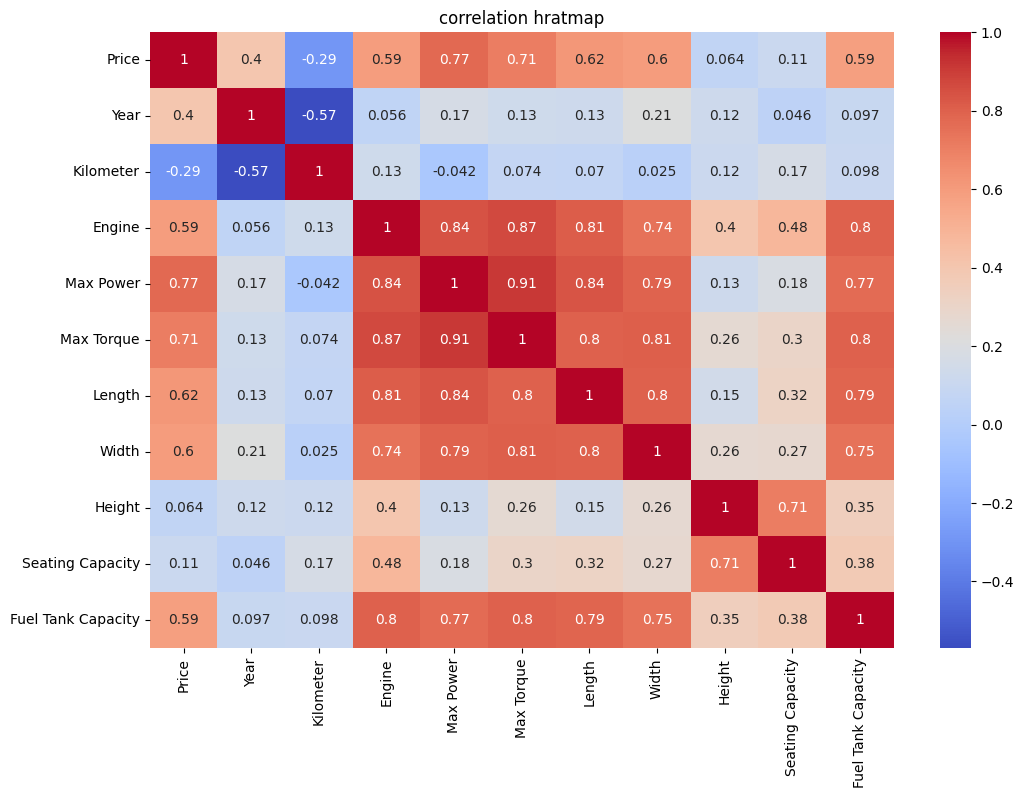

In [60]:
corr = df_clean.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr , annot=True , cmap="coolwarm")
plt.title("correlation hratmap")
plt.show()


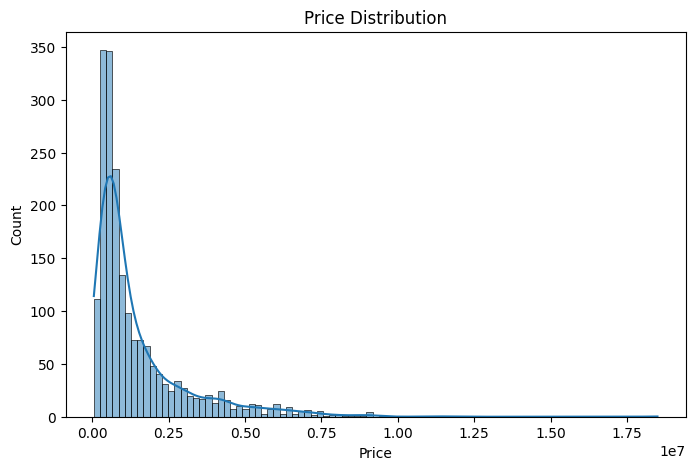

In [61]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

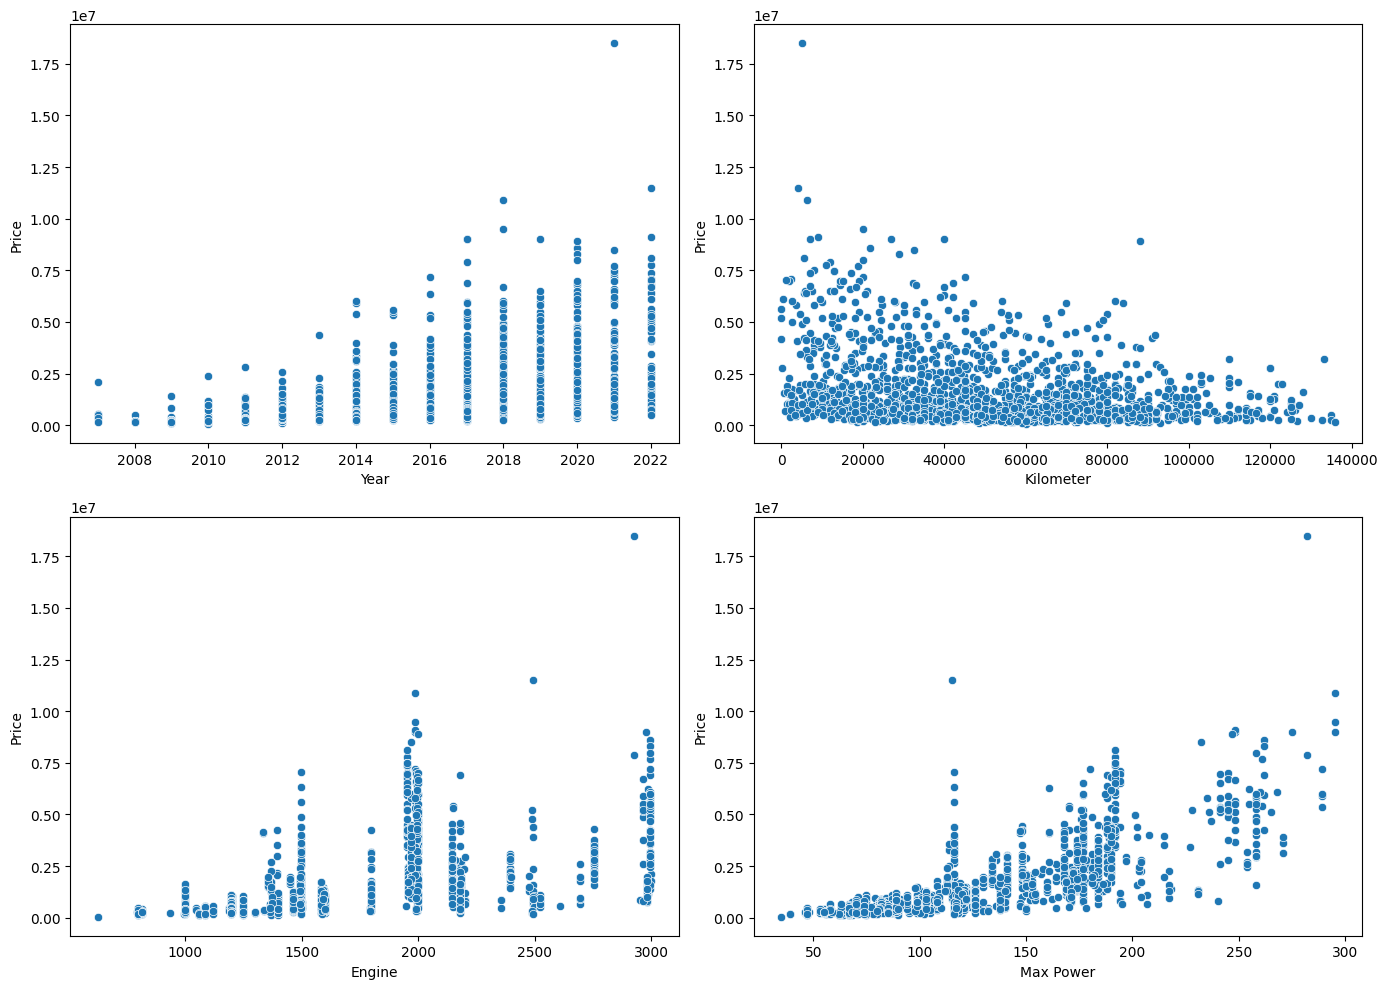

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(x="Year", y="Price", data=df_clean, ax=axes[0,0])
sns.scatterplot(x="Kilometer", y="Price", data=df_clean, ax=axes[0,1])
sns.scatterplot(x="Engine", y="Price", data=df_clean, ax=axes[1,0])
sns.scatterplot(x="Max Power", y="Price", data=df_clean, ax=axes[1,1])

plt.tight_layout()
plt.show()

In [63]:
from sklearn.ensemble import RandomForestRegressor

numeric_df = df_clean.select_dtypes(include='number')

X = numeric_df.drop(columns=["Price"])
y = numeric_df["Price"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)


def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name}")
    print(f"MAE:  {mae:,.2f}")
    print(f"MSE:  {mse:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R2:   {r2:.4f}")

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression
MAE:  569,195.87
MSE:  742,580,072,428.79
RMSE: 861,730.86
R2:   0.7322

Random Forest
MAE:  253,912.38
MSE:  316,645,083,395.85
RMSE: 562,712.26
R2:   0.8858


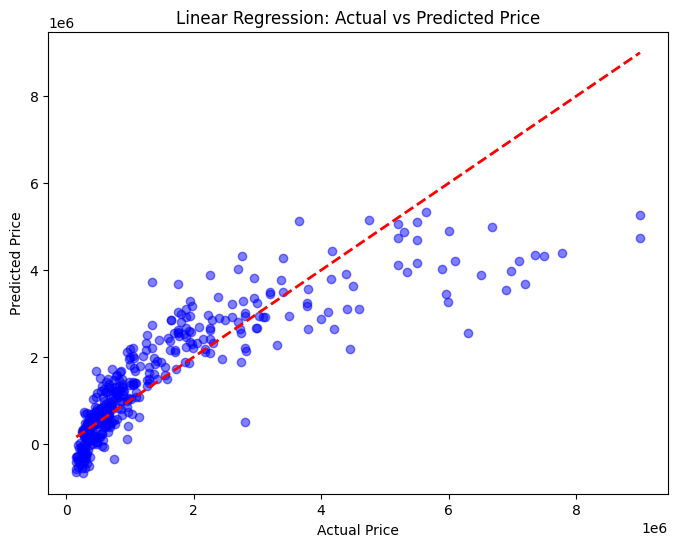

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Price")
plt.show()